### **Logistic Regression**

In [69]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [41]:
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
 
# Load the penguins dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' classes
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()
# Make a copy to avoid the warning

# Initialize the LabelEncoder
le = LabelEncoder()
# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DataFrame
print(df_filtered[['species', 'class_encoded']])

# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded'] # Target variable
X = df_filtered.drop(['class_encoded'], axis=1)



#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)
#Train the logistic regression model. 
# Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='saga')
logreg.fit(X_train, y_train)
# Predict on the testing data
y_pred = logreg.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]


ValueError: could not convert string to float: 'Adelie'

In [43]:
# Load the penguins dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' classes
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()  # Make a copy to avoid the warning

# Initialize the LabelEncoder
le = LabelEncoder()
# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DataFrame
print(df_filtered[['species', 'class_encoded']])


# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded'] # Target variable
X_temp = df_filtered.drop(['species','class_encoded'], axis=1)
categorical_cols = ['island', 'sex']
X = pd.get_dummies(X_temp, columns=categorical_cols, drop_first=True)

print(X)


       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0              39.1           18.7              181.0       3750.0   
1              39.5           17.4              186.0       3800.0   
2              40.3           18.0              195.0       3250.0   
4              36.7           19.3              193.0       3450.0   
5              39.3           20.6              190.0       3650.0   
..              ...            ...                ...          ...   
215            55.8           19.8              207.0       4000.0   
216            43.5           18.1              202.0   

In [45]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#Train the logistic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='saga', max_iter=8000)
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

Accuracy: 0.8604651162790697
[[ 0.1563387  -0.01051025 -0.02007008 -0.00092966  0.01187707 -0.00686698
   0.00071917]] [-0.00086852]


In [ ]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#Train the logistic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

Accuracy: 1.0
[[ 1.4972774  -1.3855492  -0.14189846 -0.00358871  0.72189036 -0.55196997
  -0.22201155]] [-0.07582589]


#### **Feature scaling using standard scalar**

**Saga Solver with feature scaling with StandardScalar**

In [71]:
# Load the penguins dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' classes
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()  # Make a copy to avoid the warning

# Initialize the LabelEncoder
le = LabelEncoder()
# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DataFrame
print(df_filtered[['species', 'class_encoded']])

# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded'] # Target variable
X_temp = df_filtered.drop(['species','class_encoded'], axis=1)

# Feature scaling
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
scaler = StandardScaler()
X_temp[numeric_cols] = scaler.fit_transform(X_temp[numeric_cols])

# Encoding categorical variables
categorical_cols = ['island', 'sex']
X = pd.get_dummies(X_temp, columns=categorical_cols, drop_first=True)

print(X)


#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#Train the logistic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='saga')
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0         -0.530176       0.277225          -1.516752     0.081170   
1         -0.457166      -0.816731          -0.822304     0.196206   
2         -0.311146      -0.311829           0.427702    -1.069186   
4         -0.968236       0.782127           0.149923    -0.609044   
5         -0.493671       1.876083          -0.266746    -0.148901   
..              ...            ...                ...          ...   
215        2.517993       1.202879           2.094377     0.656348   
216        0.272935      -0.227678           1.399929   

**Liblinear Solver with feature scaling with StandardScalar**

In [72]:
# Load the penguins dataset
df = sns.load_dataset("penguins")
df.dropna(inplace=True)

# Filter rows for 'Adelie' and 'Chinstrap' classes
selected_classes = ['Adelie', 'Chinstrap']
df_filtered = df[df['species'].isin(selected_classes)].copy()  # Make a copy to avoid the warning

# Initialize the LabelEncoder
le = LabelEncoder()
# Encode the species column
y_encoded = le.fit_transform(df_filtered['species'])
df_filtered['class_encoded'] = y_encoded

# Display the filtered and encoded DataFrame
print(df_filtered[['species', 'class_encoded']])

# Split the data into features (X) and target variable (y)
y = df_filtered['class_encoded'] # Target variable
X_temp = df_filtered.drop(['species','class_encoded'], axis=1)

# Feature scaling
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
scaler = StandardScaler()
X_temp[numeric_cols] = scaler.fit_transform(X_temp[numeric_cols])

# Encoding categorical variables
categorical_cols = ['island', 'sex']
X = pd.get_dummies(X_temp, columns=categorical_cols, drop_first=True)

print(X)


#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

#Train the logistic regression model. Here we are using saga solver to learn weights.
logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_train, y_train)

# Predict on the testing data
y_pred = logreg.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(logreg.coef_, logreg.intercept_)

       species  class_encoded
0       Adelie              0
1       Adelie              0
2       Adelie              0
4       Adelie              0
5       Adelie              0
..         ...            ...
215  Chinstrap              1
216  Chinstrap              1
217  Chinstrap              1
218  Chinstrap              1
219  Chinstrap              1

[214 rows x 2 columns]
     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  \
0         -0.530176       0.277225          -1.516752     0.081170   
1         -0.457166      -0.816731          -0.822304     0.196206   
2         -0.311146      -0.311829           0.427702    -1.069186   
4         -0.968236       0.782127           0.149923    -0.609044   
5         -0.493671       1.876083          -0.266746    -0.148901   
..              ...            ...                ...          ...   
215        2.517993       1.202879           2.094377     0.656348   
216        0.272935      -0.227678           1.399929   

#### **Logistic regression First/Second-Order Methods**

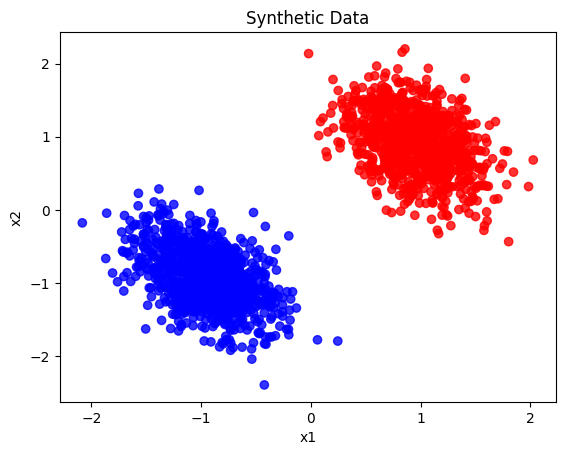

Iteration 1/20: Weights = [0.04742072 0.04579933 0.        ], Loss = 0.6506695609837094
Iteration 2/20: Weights = [9.27243649e-02 8.94891556e-02 1.40922087e-08], Loss = 0.6119520902518338
Iteration 3/20: Weights = [1.36015469e-01 1.31174375e-01 1.18130004e-07], Loss = 0.5766438674993185
Iteration 4/20: Weights = [1.77400194e-01 1.70961788e-01 4.40325440e-07], Loss = 0.5444170956213272
Iteration 5/20: Weights = [2.16984184e-01 2.08957852e-01 1.13883604e-06], Loss = 0.5149692844302258
Iteration 6/20: Weights = [2.54870908e-01 2.45266927e-01 2.38383915e-06], Loss = 0.4880239894416539
Iteration 7/20: Weights = [2.91160432e-01 2.79989996e-01 4.34414981e-06], Loss = 0.46333047791485626
Iteration 8/20: Weights = [3.25948583e-01 3.13223767e-01 7.17794101e-06], Loss = 0.4406626609080987
Iteration 9/20: Weights = [3.59326411e-01 3.45060110e-01 1.10268847e-05], Loss = 0.4198175643356745
Iteration 10/20: Weights = [3.91379896e-01 3.75585741e-01 1.60129717e-05], Loss = 0.4006135474123554
Iteration 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
 
# Generate synthetic data
np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]
X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

X = StandardScaler().fit_transform(X)

# Visualize data
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic Data")
plt.show()

# Add bias term
X_bias = np.c_[X, np.ones(X.shape[0])]

# Define sigmoid function
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def compute_loss(X, Y, W):
  p = sigmoid(X @ W)
  eps = 1e-9
  return -np.mean(Y*np.log(p+eps) + (1-Y)*np.log(1-p+eps))

def compute_grad(X, Y, W):
  return (X.T @ (sigmoid(X @ W)-Y)) / len(Y) 

# Initialize weights
Weights = np.zeros(X_bias.shape[1])
alpha =  0.1
losses = []

# Batch gradient descent
for i in range(20):
  grad = compute_grad(X_bias, y, Weights)
  Weights -= alpha * grad
  loss = compute_loss(X_bias, y, Weights)
  losses.append(loss)
  print(f"Iteration {i+1}/20: Weights = {Weights}, Loss = {loss}")

print("Final weights (BGD):", Weights)
print("Final loss (BGD):", losses[-1])



**Without Standard scaling**

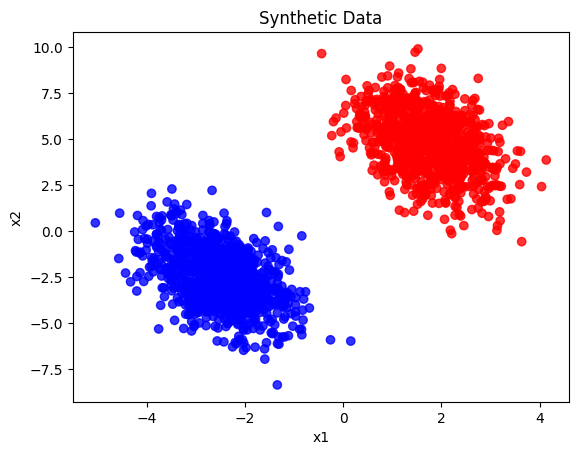

Iteration 1/20: Weights = [0.10585709 0.18203713 0.        ], Loss = 0.3553
Iteration 2/20: Weights = [ 0.17058513  0.27733096 -0.00347943], Loss = 0.2447
Iteration 3/20: Weights = [ 0.21805237  0.34013409 -0.00751785], Loss = 0.1901
Iteration 4/20: Weights = [ 0.25616947  0.38691355 -0.01149835], Loss = 0.1570
Iteration 5/20: Weights = [ 0.28831956  0.42416834 -0.01528425], Loss = 0.1345
Iteration 6/20: Weights = [ 0.31628173  0.45510574 -0.01885265], Loss = 0.1182
Iteration 7/20: Weights = [ 0.34111832  0.48154389 -0.02221227], Loss = 0.1057
Iteration 8/20: Weights = [ 0.36351978  0.50461376 -0.02538028], Loss = 0.0958
Iteration 9/20: Weights = [ 0.38396285  0.52506714 -0.02837509], Loss = 0.0877
Iteration 10/20: Weights = [ 0.40279198  0.54342935 -0.03121392], Loss = 0.0810
Iteration 11/20: Weights = [ 0.42026494  0.56008201 -0.0339122 ], Loss = 0.0753
Iteration 12/20: Weights = [ 0.43658023  0.57531113 -0.03648346], Loss = 0.0704
Iteration 13/20: Weights = [ 0.45189424  0.58933663 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
 
# Generate synthetic data
np.random.seed(0)
centers = [[-5, 0], [5, 1.5]]
X, y = make_blobs(n_samples=2000, centers=centers, random_state=5)
transformation = [[0.5, 0.5], [-0.5, 1.5]]
X = np.dot(X, transformation)

# Visualize data
plt.scatter(X[:,0], X[:,1], c=y, cmap="bwr", alpha=0.8)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic Data")
plt.show()

# Add bias term
X_bias = np.c_[X, np.ones(X.shape[0])]

# Define sigmoid function
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

def compute_loss(X, Y, W):
  p = sigmoid(X @ W)
  eps = 1e-9
  return -np.mean(Y*np.log(p+eps) + (1-Y)*np.log(1-p+eps))

def compute_grad(X, Y, W):
  return (X.T @ (sigmoid(X @ W)-Y)) / len(Y) 

# Initialize weights
Weights = np.zeros(X_bias.shape[1])
alpha =  0.1
losses = []

# Batch gradient descent
for i in range(20):
  grad = compute_grad(X_bias, y, Weights)
  Weights -= alpha * grad
  loss = compute_loss(X_bias, y, Weights)
  losses.append(loss)
  print(f"Iteration {i+1}/20: Weights = {Weights}, Loss = {loss:.4f}")

print("Final weights (BGD):", Weights)
print("Final loss (BGD):", losses[-1])



In [32]:
def compute_hessian(X, y, w):
    p = sigmoid(X @ w)
    S = np.diag(p * (1 - p))
    return (X.T @ S @ X) / len(y)

# Newton's Method
w_newton = np.zeros(X_bias.shape[1])
losses_newton = []

for i in range(20):
    grad = compute_grad(X_bias, y, w_newton)
    hess = compute_hessian(X_bias, y, w_newton)
    delta = np.linalg.solve(hess, grad)  # Solve H*delta = grad
    w_newton -= delta
    loss = compute_loss(X_bias, y, w_newton)
    losses_newton.append(loss)
    print(f"Iteration {i+1}/20: Weights = {Weights}, Loss = {loss:.4f}")


print("Final weights (Newton):", w_newton)
print("Final loss (Newton):", losses_newton[-1])

Iteration 1/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.1452
Iteration 2/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0528
Iteration 3/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0203
Iteration 4/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0080
Iteration 5/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0032
Iteration 6/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0013
Iteration 7/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0005
Iteration 8/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0002
Iteration 9/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0001
Iteration 10/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0000
Iteration 11/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0000
Iteration 12/20: Weights = [ 0.53927699  0.66486896 -0.05363315], Loss = 0.0000
Iteration 13/20: Weights = [ 0.53927699  0.664868

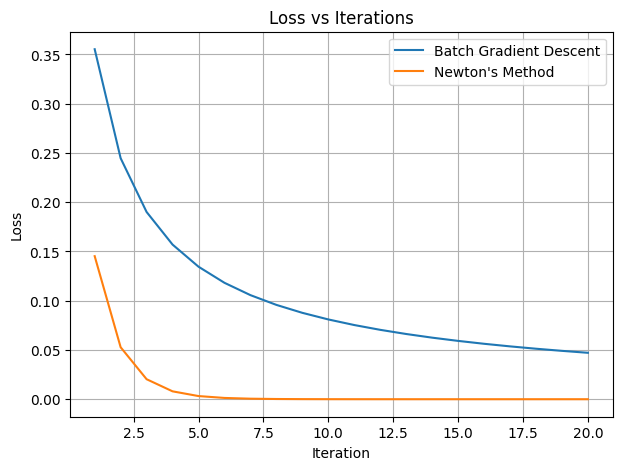

In [34]:
# Plot Losses 
plt.figure(figsize=(7,5))
plt.plot(range(1, 21), losses, label="Batch Gradient Descent")
plt.plot(range(1, 21), losses_newton, label="Newton's Method")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iterations")
plt.legend()
plt.grid(True)
plt.show()

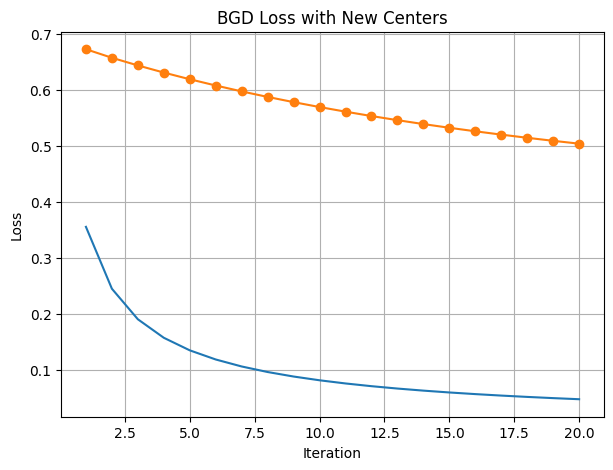

In [38]:
centers = [[2, 2], [5, 1.5]]
X_new, y_new = make_blobs(n_samples=2000, centers=centers, random_state=5)
X_new = np.dot(X_new, transformation)
X_new_bias = np.c_[X_new, np.ones(X_new.shape[0])]

# Run BGD again on new data
w_new = np.zeros(X_new_bias.shape[1])
losses_new = []

for i in range(20):
    grad = compute_grad(X_new_bias, y_new, w_new)
    w_new -= alpha * grad
    losses_new.append(compute_loss(X_new_bias, y_new, w_new))

plt.figure(figsize=(7,5))
plt.plot(range(1, 21), losses, label="Batch Gradient Descent")
plt.plot(range(1, 21), losses_new, marker='o', label="BGD With New Configuration")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("BGD Loss with New Centers")
plt.grid(True)
plt.show()